# Task 1 — Inductive Biases and Feature Representations

Compares a frozen ResNet-50 (CNN), ViT-B/16 (Vision Transformer), and CLIP ViT-B/32 under controlled image interventions on STL-10, following the same idempotent, checkpoint-on-completion notebook style as Tasks 2–4.

**Pipeline**
0. Setup
1. Data (STL-10, stratified head-train/val split, class-balanced 500-image eval subset)
2. Frozen backbones + feature extractors
3. Linear classifier heads (+ CLIP zero-shot)
4. Clean baseline
5. Color bias (grayscale + fixed hue rotation)
6. Shape vs. texture (cue-conflict via Gatys-style optimization-based style transfer)
7. Translation
8. Patch structure (4x4 shuffle)
9. Representation analysis (cosine stability + t-SNE)
10. Summary

**Caching strategy**: the two genuinely expensive steps are cue-conflict generation (iterative per-image optimization) and frozen feature extraction for the head-training set, so those are cached to disk and skipped on a subsequent Run All. Everything else here is a single frozen forward pass over at most 500 images and is cheap enough to just recompute if a session restarts.

## 0. Setup

In [1]:
!pip install -q open_clip_torch scikit-image --no-input


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 35.7 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.2 MB/s eta 0:00:00


In [2]:
import os, json, random, math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as T
import torchvision.transforms.functional as TF
from torchvision.models import resnet50, ResNet50_Weights, vit_b_16, ViT_B_16_Weights
from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from sklearn.manifold import TSNE
from skimage.metrics import structural_similarity as ssim_fn
import open_clip
import matplotlib.pyplot as plt

def set_seed(seed=6304):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(6304)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

WORK_DIR = '/kaggle/working'
CACHE_DIR = os.path.join(WORK_DIR, 'cache')
CKPT_DIR = os.path.join(WORK_DIR, 'checkpoints')
os.makedirs(CACHE_DIR, exist_ok=True)
os.makedirs(CKPT_DIR, exist_ok=True)

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)
CLIP_MEAN = (0.48145466, 0.4578275, 0.40821073)
CLIP_STD = (0.26862954, 0.26130258, 0.27577711)
IMG_SIZE = 224


Device: cuda


## 1. Data

**Dataset choice — STL-10** (the recommended option). *Hypothesis*: 10 visually distinct, roughly balanced classes at moderate resolution are enough to expose architecture-driven shape/texture/color biases without a fine-grained-classification confound. *Metric*: clean top-1 accuracy / macro-F1 per backbone (Section 4) as a sanity check that all three backbones can actually learn the task before interventions are interpreted.

All interventions are built on a common, unnormalized 224x224 RGB tensor (`Resize(224)` + `ToTensor()`, values in [0,1]); each backbone's own normalization is applied only immediately before that backbone's forward pass.

In [3]:
DATA_ROOT = '/kaggle/working/data'
stl_train_raw = torchvision.datasets.STL10(DATA_ROOT, split='train', download=True)
stl_test_raw = torchvision.datasets.STL10(DATA_ROOT, split='test', download=True)
CLASSES = list(stl_train_raw.classes)
NUM_CLASSES = len(CLASSES)
print('Classes:', CLASSES)
print('Train (official):', len(stl_train_raw), '| Test (official):', len(stl_test_raw))


100%|██████████| 2.64G/2.64G [12:42<00:00, 3.46MB/s] 


Classes: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']
Train (official): 5000 | Test (official): 8000


In [4]:
base_tf = T.Compose([T.Resize((IMG_SIZE, IMG_SIZE)), T.ToTensor()])

class STLBaseDataset(Dataset):
    """Wraps an STL-10 split, returning a common unnormalized 224x224 RGB tensor plus label."""
    def __init__(self, raw_ds):
        self.raw_ds = raw_ds
    def __len__(self):
        return len(self.raw_ds)
    def __getitem__(self, idx):
        img, label = self.raw_ds[idx]
        return base_tf(img), label

stl_train_base = STLBaseDataset(stl_train_raw)
stl_test_base = STLBaseDataset(stl_test_raw)


In [5]:
# --- Stratified 80/20 split of the official training partition (seed 6304) for head training ---
set_seed(6304)
train_labels = np.array(stl_train_raw.labels)
head_train_idx, head_val_idx = train_test_split(
    np.arange(len(train_labels)), test_size=0.2, stratify=train_labels, random_state=6304)
print(f'Head train: {len(head_train_idx)}  Head val: {len(head_val_idx)}')

head_train_loader = DataLoader(Subset(stl_train_base, head_train_idx), batch_size=64, shuffle=False, num_workers=2)
head_val_loader = DataLoader(Subset(stl_train_base, head_val_idx), batch_size=64, shuffle=False, num_workers=2)


Head train: 4000  Head val: 1000


In [6]:
# --- Class-balanced 500-image evaluation subset from the official test partition (seed 6304) ---
# STL-10's test split has 800 images/class, comfortably more than the 50/class needed for 500 total,
# so this subset is exactly balanced -- no imbalance to document.
test_labels = np.array(stl_test_raw.labels)
rng = np.random.RandomState(6304)
eval_idx = []
per_class = 500 // NUM_CLASSES
imbalance_log = {}
for c in range(NUM_CLASSES):
    idx_c = np.where(test_labels == c)[0]
    rng.shuffle(idx_c)
    n_take = min(per_class, len(idx_c))
    if n_take < per_class:
        imbalance_log[CLASSES[c]] = n_take
    eval_idx.extend(idx_c[:n_take].tolist())
eval_idx = sorted(eval_idx)
print(f'Eval subset size: {len(eval_idx)}  (target 500, {per_class}/class)')
print('Classes with fewer than target available:', imbalance_log if imbalance_log else 'none')

with open(os.path.join(CACHE_DIR, 'eval_subset_ids.json'), 'w') as f:
    json.dump({'eval_idx': eval_idx, 'source_split': 'test'}, f)

eval_labels = test_labels[eval_idx]
eval_loader = DataLoader(Subset(stl_test_base, eval_idx), batch_size=64, shuffle=False, num_workers=2)


Eval subset size: 500  (target 500, 50/class)
Classes with fewer than target available: none


## 2. Frozen backbones + feature extractors

In [7]:
resnet_model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2).to(device).eval()
for p in resnet_model.parameters():
    p.requires_grad_(False)
resnet_trunk = nn.Sequential(*list(resnet_model.children())[:-1])  # up to global-avg-pool, 2048-d

vit_model = vit_b_16(weights=ViT_B_16_Weights.IMAGENET1K_V1).to(device).eval()
for p in vit_model.parameters():
    p.requires_grad_(False)

def vit_cls_token(model, x):
    """Replicates torchvision's VisionTransformer.forward up to (but excluding) the classifier head,
    returning the final CLS-token embedding (768-d)."""
    x = model._process_input(x)
    n = x.shape[0]
    batch_class_token = model.class_token.expand(n, -1, -1)
    x = torch.cat([batch_class_token, x], dim=1)
    x = model.encoder(x)
    return x[:, 0]

clip_model, _, _ = open_clip.create_model_and_transforms('ViT-B-32', pretrained='openai')
clip_model = clip_model.to(device).eval()
for p in clip_model.parameters():
    p.requires_grad_(False)
clip_tokenizer = open_clip.get_tokenizer('ViT-B-32')

print('All three backbones loaded frozen.')


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 160MB/s] 


Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 184MB/s]  


open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


All three backbones loaded frozen.


In [8]:
def normalize_for(backbone, x):
    if backbone == 'clip':
        mean, std = CLIP_MEAN, CLIP_STD
    else:
        mean, std = IMAGENET_MEAN, IMAGENET_STD
    mean_t = torch.tensor(mean, device=x.device).view(1, 3, 1, 1)
    std_t = torch.tensor(std, device=x.device).view(1, 3, 1, 1)
    return (x - mean_t) / std_t

@torch.no_grad()
def extract_features(backbone, base_tensor_batch):
    """base_tensor_batch: (N,3,224,224) in [0,1]. Returns (N, feat_dim) on CPU."""
    x = base_tensor_batch.to(device)
    x = normalize_for(backbone, x)
    if backbone == 'resnet':
        feats = resnet_trunk(x).flatten(1)
    elif backbone == 'vit':
        feats = vit_cls_token(vit_model, x)
    elif backbone == 'clip':
        feats = clip_model.encode_image(x)
        feats = F.normalize(feats, dim=-1)
    else:
        raise ValueError(backbone)
    return feats.cpu()

@torch.no_grad()
def extract_features_loader(backbone, loader):
    all_feats, all_labels = [], []
    for x, y in loader:
        all_feats.append(extract_features(backbone, x))
        all_labels.append(y if torch.is_tensor(y) else torch.tensor(y))
    return torch.cat(all_feats), torch.cat(all_labels)

BACKBONES = ['resnet', 'vit', 'clip']


## 3. Linear classifier heads (+ CLIP zero-shot)

One linear head per backbone: AdamW(lr=1e-3, weight_decay=1e-4), up to 50 epochs, early stopping after 5 epochs without improved validation accuracy, seed 6304. Frozen features for the head-train/val split are extracted once and cached, since re-extracting them is the one non-trivial cost in this section.

In [9]:
head_feat_cache = os.path.join(CACHE_DIR, 'head_features.pt')
if os.path.exists(head_feat_cache):
    print('Loading cached head-training features.')
    cached = torch.load(head_feat_cache)
else:
    cached = {}
    for bb in BACKBONES:
        print(f'Extracting {bb} features for head train/val...')
        tr_f, tr_y = extract_features_loader(bb, head_train_loader)
        va_f, va_y = extract_features_loader(bb, head_val_loader)
        cached[bb] = {'train_feats': tr_f, 'train_labels': tr_y, 'val_feats': va_f, 'val_labels': va_y}
    torch.save(cached, head_feat_cache)
print('Feature dims:', {bb: cached[bb]['train_feats'].shape[1] for bb in BACKBONES})


Extracting resnet features for head train/val...
Extracting vit features for head train/val...
Extracting clip features for head train/val...
Feature dims: {'resnet': 2048, 'vit': 768, 'clip': 512}


In [10]:
def train_linear_head(tag, feats_train, y_train, feats_val, y_val, feat_dim,
                       num_classes=10, epochs=50, patience=5, seed=6304):
    set_seed(seed)
    head = nn.Linear(feat_dim, num_classes).to(device)
    opt = torch.optim.AdamW(head.parameters(), lr=1e-3, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()

    Xtr, ytr = feats_train.to(device), y_train.to(device)
    Xva, yva = feats_val.to(device), y_val.to(device)

    best_val_acc, best_state, epochs_no_improve = -1.0, None, 0
    for epoch in range(1, epochs + 1):
        head.train()
        opt.zero_grad()
        out = head(Xtr)
        loss = criterion(out, ytr)
        loss.backward()
        opt.step()

        head.eval()
        with torch.no_grad():
            val_acc = (head(Xva).argmax(1) == yva).float().mean().item()

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.clone() for k, v in head.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                break

    head.load_state_dict(best_state)
    print(f'[{tag}] best val acc = {best_val_acc:.4f} (stopped at epoch {epoch})')
    return head, best_val_acc

heads = {}
for bb in BACKBONES:
    ckpt_path = os.path.join(CKPT_DIR, f'head_{bb}.pth')
    feat_dim = cached[bb]['train_feats'].shape[1]
    head = nn.Linear(feat_dim, NUM_CLASSES).to(device)
    if os.path.exists(ckpt_path):
        head.load_state_dict(torch.load(ckpt_path, map_location=device))
        print(f'[{bb}] loaded cached head checkpoint.')
    else:
        head, _ = train_linear_head(bb, cached[bb]['train_feats'], cached[bb]['train_labels'],
                                     cached[bb]['val_feats'], cached[bb]['val_labels'], feat_dim)
        torch.save(head.state_dict(), ckpt_path)
    heads[bb] = head


[resnet] best val acc = 0.9630 (stopped at epoch 50)
[vit] best val acc = 0.9720 (stopped at epoch 41)
[clip] best val acc = 0.9790 (stopped at epoch 39)


In [11]:
# --- CLIP zero-shot classifier: "a photo of a {class}." ---
@torch.no_grad()
def clip_zeroshot_logits(image_feats_normed):
    prompts = [f'a photo of a {c}.' for c in CLASSES]
    text_tokens = clip_tokenizer(prompts).to(device)
    text_feats = clip_model.encode_text(text_tokens)
    text_feats = F.normalize(text_feats, dim=-1)
    logit_scale = clip_model.logit_scale.exp().cpu()
    return logit_scale * (image_feats_normed @ text_feats.cpu().T)

print('CLIP zero-shot text classifier ready.')


CLIP zero-shot text classifier ready.


## 4. Clean baseline

Top-1 accuracy, macro-F1, and mean maximum (softmax) confidence for the three trained heads and zero-shot CLIP, on the clean 500-image evaluation subset. This is the reference every later intervention is compared against, both in absolute terms and relative to each model's own baseline.

In [12]:
eval_feat_cache = os.path.join(CACHE_DIR, 'eval_clean_features.pt')
if os.path.exists(eval_feat_cache):
    eval_feats = torch.load(eval_feat_cache)
else:
    eval_feats = {bb: extract_features_loader(bb, eval_loader) for bb in BACKBONES}
    torch.save(eval_feats, eval_feat_cache)

eval_labels_t = eval_feats['resnet'][1]  # same order/labels for every backbone
assert torch.equal(eval_labels_t, eval_feats['vit'][1]) and torch.equal(eval_labels_t, eval_feats['clip'][1])


In [13]:
def head_predict(bb, feats):
    head = heads[bb]
    head.eval()
    with torch.no_grad():
        logits = head(feats.to(device)).cpu()
    probs = F.softmax(logits, dim=1)
    preds = probs.argmax(1)
    conf = probs.max(1).values
    return preds, conf

def clip_zeroshot_predict(feats_normed):
    logits = clip_zeroshot_logits(feats_normed)
    probs = F.softmax(logits, dim=1)
    preds = probs.argmax(1)
    conf = probs.max(1).values
    return preds, conf

def evaluate_all_models(feats_dict, labels, tag):
    results = {}
    for bb in BACKBONES:
        preds, conf = head_predict(bb, feats_dict[bb][0])
        acc = accuracy_score(labels, preds)
        f1 = f1_score(labels, preds, average='macro')
        results[f'{bb}_head'] = {'preds': preds, 'conf': conf, 'acc': acc, 'f1': f1, 'mean_conf': conf.mean().item()}
    zs_preds, zs_conf = clip_zeroshot_predict(feats_dict['clip'][0])
    acc = accuracy_score(labels, zs_preds)
    f1 = f1_score(labels, zs_preds, average='macro')
    results['clip_zeroshot'] = {'preds': zs_preds, 'conf': zs_conf, 'acc': acc, 'f1': f1, 'mean_conf': zs_conf.mean().item()}
    print(f'--- {tag} ---')
    for name, r in results.items():
        print(f'  {name:<14} acc={r["acc"]*100:5.2f}%  macro-F1={r["f1"]*100:5.2f}%  mean_conf={r["mean_conf"]:.3f}')
    return results

clean_results = evaluate_all_models(eval_feats, eval_labels_t.numpy(), 'Clean Baseline')


--- Clean Baseline ---
  resnet_head    acc=95.20%  macro-F1=95.20%  mean_conf=0.670
  vit_head       acc=96.40%  macro-F1=96.41%  mean_conf=0.847
  clip_head      acc=95.40%  macro-F1=95.37%  mean_conf=0.123
  clip_zeroshot  acc=93.40%  macro-F1=93.28%  mean_conf=0.926


## 5. Color bias

**Additional color intervention choice — fixed hue rotation** (over palette transfer or class-swapped statistics), because it isolates a single, precisely controllable chromatic factor (the hue channel in HSV) while leaving luminance-carried shape and texture information exactly intact — a cleaner ablation than a palette swap, which conflates several statistics at once. *Hypothesis*: for classes with a color-diagnostic cue (e.g. sky/ocean blue vs. foliage green), hue rotation will hurt accuracy more than grayscale, since grayscale still preserves relative luminance contrast while hue rotation actively misleads any color-based decision rule. *Metric*: accuracy change and prediction consistency relative to clean, per backbone.

In [14]:
def grayscale_transform(x):
    return TF.rgb_to_grayscale(x, num_output_channels=3)

HUE_FACTOR = 0.3  # fixed rotation, within torchvision's [-0.5, 0.5] range
def hue_rotate_transform(x):
    return torch.stack([TF.adjust_hue(img, HUE_FACTOR) for img in x])

@torch.no_grad()
def build_transformed_loader_features(transform_fn):
    """Applies transform_fn to every eval-subset base image and extracts features per backbone."""
    feats = {bb: [] for bb in BACKBONES}
    labels_out = []
    for x, y in eval_loader:
        x_t = transform_fn(x)
        for bb in BACKBONES:
            feats[bb].append(extract_features(bb, x_t))
        labels_out.append(y)
    for bb in BACKBONES:
        feats[bb] = (torch.cat(feats[bb]), torch.cat(labels_out))
    return feats

gray_feats = build_transformed_loader_features(grayscale_transform)
hue_feats = build_transformed_loader_features(hue_rotate_transform)


In [15]:
def consistency(preds_a, preds_b):
    return (preds_a == preds_b).float().mean().item()

def summarize_color_bias(feats_dict, tag):
    results = evaluate_all_models(feats_dict, eval_labels_t.numpy(), tag)
    print(f'--- {tag} vs Clean ---')
    for name in results:
        acc_delta = (results[name]['acc'] - clean_results[name]['acc']) * 100
        cons = consistency(torch.tensor(results[name]['preds']), torch.tensor(clean_results[name]['preds']))
        print(f'  {name:<14} acc Δ={acc_delta:+5.2f} pts   consistency={cons*100:5.2f}%')
    return results

gray_results = summarize_color_bias(gray_feats, 'Grayscale')
hue_results = summarize_color_bias(hue_feats, f'Hue rotation (factor={HUE_FACTOR})')


--- Grayscale ---
  resnet_head    acc=93.00%  macro-F1=93.04%  mean_conf=0.703
  vit_head       acc=94.20%  macro-F1=94.22%  mean_conf=0.846
  clip_head      acc=91.80%  macro-F1=91.76%  mean_conf=0.121
  clip_zeroshot  acc=89.80%  macro-F1=89.76%  mean_conf=0.914
--- Grayscale vs Clean ---
  resnet_head    acc Δ=-2.20 pts   consistency=96.00%
  vit_head       acc Δ=-2.20 pts   consistency=96.60%
  clip_head      acc Δ=-3.60 pts   consistency=93.40%
  clip_zeroshot  acc Δ=-3.60 pts   consistency=92.40%
--- Hue rotation (factor=0.3) ---
  resnet_head    acc=92.40%  macro-F1=92.46%  mean_conf=0.708
  vit_head       acc=93.00%  macro-F1=93.00%  mean_conf=0.819
  clip_head      acc=92.20%  macro-F1=92.28%  mean_conf=0.120
  clip_zeroshot  acc=90.80%  macro-F1=90.69%  mean_conf=0.899
--- Hue rotation (factor=0.3) vs Clean ---
  resnet_head    acc Δ=-2.80 pts   consistency=94.40%
  vit_head       acc Δ=-3.40 pts   consistency=95.00%
  clip_head      acc Δ=-3.20 pts   consistency=93.80%
  cl

/tmp/ipykernel_58/3577939903.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  cons = consistency(torch.tensor(results[name]['preds']), torch.tensor(clean_results[name]['preds']))
/tmp/ipykernel_58/3577939903.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  cons = consistency(torch.tensor(results[name]['preds']), torch.tensor(clean_results[name]['preds']))


## 6. Shape vs. texture (cue-conflict)

**Style-transfer implementation choice**: Gatys et al.'s optimization-based neural style transfer (pretrained VGG-19 features, content + Gram-matrix style loss, image itself as the optimized variable) rather than a feed-forward AdaIN decoder — AdaIN needs an externally pretrained decoder network with no reliable, license-clear download path from inside a Kaggle session, whereas Gatys-style transfer only needs torchvision's standard pretrained VGG-19 and gives an explicit, continuously tunable **style strength** (the style/content loss weight ratio), which is one of the required design choices to justify here.

**Class pairs & style strength**: 5 unordered pairs chosen for maximal visual/semantic separation (`cat`–`truck`, `dog`–`airplane`, `horse`–`ship`, `bird`–`car`, `deer`–`monkey`), both directions generated → 10 directed (content, style) combinations. Style weight is set high relative to content weight (`style_weight=1e6`, `content_weight=1`) so the texture cue is strong enough to matter, with an automated **rejection rule** (SSIM(stylized, content) below a fixed threshold, or a near-constant degenerate output) applied *before* any model sees the images, so predictions never influence which images are kept. *Hypothesis*: following Geirhos et al. (2019), the CNN (ResNet-50) will show lower shape bias (more texture-reliant) than ViT-B/16 and CLIP. *Metric*: Shape Bias% and Coverage%.

In [16]:
vgg = torchvision.models.vgg19(weights=torchvision.models.VGG19_Weights.IMAGENET1K_V1).features.to(device).eval()
for p in vgg.parameters():
    p.requires_grad_(False)
VGG_MEAN = torch.tensor(IMAGENET_MEAN, device=device).view(1, 3, 1, 1)
VGG_STD = torch.tensor(IMAGENET_STD, device=device).view(1, 3, 1, 1)

CONTENT_LAYERS = ['21']       # relu4_2
STYLE_LAYERS = ['0', '5', '10', '19', '28']  # relu1_1, relu2_1, relu3_1, relu4_1, relu5_1

def vgg_layer_outputs(x, layers):
    x = (x - VGG_MEAN) / VGG_STD
    outputs = {}
    for name, layer in vgg._modules.items():
        x = layer(x)
        if name in layers:
            outputs[name] = x
        if name == layers[-1]:
            break
    return outputs

def gram_matrix(feat):
    b, c, h, w = feat.shape
    f = feat.view(b, c, h * w)
    return torch.bmm(f, f.transpose(1, 2)) / (c * h * w)

def style_transfer(content_img, style_img, num_steps=150, style_weight=1e6, content_weight=1.0, lr=0.05):
    """content_img, style_img: (1,3,224,224) in [0,1]. Returns stylized image in [0,1], detached."""
    content_img = content_img.to(device)
    style_img = style_img.to(device)
    content_targets = vgg_layer_outputs(content_img, CONTENT_LAYERS + STYLE_LAYERS)
    style_targets = vgg_layer_outputs(style_img, CONTENT_LAYERS + STYLE_LAYERS)
    style_grams = {l: gram_matrix(style_targets[l]) for l in STYLE_LAYERS}

    input_img = content_img.clone().requires_grad_(True)
    opt = torch.optim.Adam([input_img], lr=lr)

    for step in range(num_steps):
        opt.zero_grad()
        outs = vgg_layer_outputs(input_img.clamp(0, 1), CONTENT_LAYERS + STYLE_LAYERS)
        c_loss = sum(F.mse_loss(outs[l], content_targets[l]) for l in CONTENT_LAYERS)
        s_loss = sum(F.mse_loss(gram_matrix(outs[l]), style_grams[l]) for l in STYLE_LAYERS)
        loss = content_weight * c_loss + style_weight * s_loss
        loss.backward()
        opt.step()

    return input_img.detach().clamp(0, 1).cpu()


Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:02<00:00, 213MB/s] 


In [17]:
CUE_PAIRS = [('cat', 'truck'), ('dog', 'airplane'), ('horse', 'ship'), ('bird', 'car'), ('deer', 'monkey')]
SSIM_THRESHOLD = 0.15
STD_THRESHOLD = 0.02  # reject near-constant degenerate outputs
CANDIDATES_PER_DIRECTION = 30

def sample_pool_indices(class_name, n, seed):
    class_id = CLASSES.index(class_name)
    pool = np.where(test_labels == class_id)[0]
    pool = np.setdiff1d(pool, eval_idx)  # avoid overlap with the clean evaluation subset
    rng_local = np.random.RandomState(seed)
    rng_local.shuffle(pool)
    return pool[:n]

def passes_rejection(stylized, content):
    s_gray = TF.rgb_to_grayscale(stylized).squeeze(0).numpy()
    c_gray = TF.rgb_to_grayscale(content).squeeze(0).numpy()
    score = ssim_fn(s_gray, c_gray, data_range=1.0)
    if stylized.std().item() < STD_THRESHOLD:
        return False, score
    return score >= SSIM_THRESHOLD, score


In [18]:
cue_cache_path = os.path.join(CACHE_DIR, 'cue_conflicts.pt')

if os.path.exists(cue_cache_path):
    print('Loading cached cue-conflict images.')
    cue_data = torch.load(cue_cache_path)
else:
    set_seed(6304)
    stylized_list, content_label_list, style_label_list = [], [], []
    n_accepted, n_rejected = 0, 0

    directed_pairs = []
    for a, b in CUE_PAIRS:
        directed_pairs.append((a, b))
        directed_pairs.append((b, a))

    for pair_idx, (content_class, style_class) in enumerate(directed_pairs):
        content_idx_pool = sample_pool_indices(content_class, CANDIDATES_PER_DIRECTION, seed=6304 + pair_idx)
        style_idx_pool = sample_pool_indices(style_class, CANDIDATES_PER_DIRECTION, seed=6304 + pair_idx + 1000)
        accepted_this_direction = 0
        print(f'Generating {content_class} (content) x {style_class} (style)...')
        for k in range(CANDIDATES_PER_DIRECTION):
            content_img, _ = stl_test_base[content_idx_pool[k]]
            style_img, _ = stl_test_base[style_idx_pool[k]]
            stylized = style_transfer(content_img.unsqueeze(0), style_img.unsqueeze(0))
            ok, score = passes_rejection(stylized.squeeze(0), content_img)
            if ok:
                stylized_list.append(stylized.squeeze(0))
                content_label_list.append(CLASSES.index(content_class))
                style_label_list.append(CLASSES.index(style_class))
                n_accepted += 1
                accepted_this_direction += 1
            else:
                n_rejected += 1
        print(f'  accepted {accepted_this_direction}/{CANDIDATES_PER_DIRECTION}')

    cue_data = {
        'images': torch.stack(stylized_list),
        'content_labels': torch.tensor(content_label_list),
        'style_labels': torch.tensor(style_label_list),
        'n_accepted': n_accepted, 'n_rejected': n_rejected,
    }
    torch.save(cue_data, cue_cache_path)

print(f"Total accepted: {cue_data['n_accepted']}  rejected: {cue_data['n_rejected']}")
assert cue_data['n_accepted'] >= 200, 'Fewer than the required 200 valid conflicts -- lower SSIM_THRESHOLD or add more candidates.'


Generating cat (content) x truck (style)...
  accepted 30/30
Generating truck (content) x cat (style)...
  accepted 30/30
Generating dog (content) x airplane (style)...
  accepted 30/30
Generating airplane (content) x dog (style)...
  accepted 30/30
Generating horse (content) x ship (style)...
  accepted 30/30
Generating ship (content) x horse (style)...
  accepted 30/30
Generating bird (content) x car (style)...
  accepted 30/30
Generating car (content) x bird (style)...
  accepted 30/30
Generating deer (content) x monkey (style)...
  accepted 30/30
Generating monkey (content) x deer (style)...
  accepted 30/30
Total accepted: 300  rejected: 0


In [19]:
@torch.no_grad()
def extract_features_tensor(bb, tensor_batch, batch_size=64):
    feats = []
    for i in range(0, len(tensor_batch), batch_size):
        feats.append(extract_features(bb, tensor_batch[i:i + batch_size]))
    return torch.cat(feats)

cue_feats = {bb: (extract_features_tensor(bb, cue_data['images']), None) for bb in BACKBONES}
content_labels = cue_data['content_labels']
style_labels = cue_data['style_labels']


In [20]:
def shape_texture_decision(preds, content_labels, style_labels):
    is_shape = preds == content_labels
    is_texture = (preds == style_labels) & (~is_shape)
    is_other = (~is_shape) & (~is_texture)
    n_shape, n_texture, n_other = is_shape.sum().item(), is_texture.sum().item(), is_other.sum().item()
    total = len(preds)
    shape_bias = 100.0 * n_shape / max(n_shape + n_texture, 1)
    coverage = 100.0 * (n_shape + n_texture) / total
    return n_shape, n_texture, n_other, shape_bias, coverage

print('--- Shape vs. Texture decisions ---')
cue_conflict_results = {}
for bb in BACKBONES:
    preds, conf = head_predict(bb, cue_feats[bb][0])
    n_s, n_t, n_o, sb, cov = shape_texture_decision(preds, content_labels, style_labels)
    cue_conflict_results[f'{bb}_head'] = {'preds': preds, 'n_shape': n_s, 'n_texture': n_t, 'n_other': n_o,
                                           'shape_bias': sb, 'coverage': cov}
    print(f'  {bb:<6} head       shape={n_s:3d} texture={n_t:3d} other={n_o:3d}  '
          f'ShapeBias={sb:5.1f}%  Coverage={cov:5.1f}%')

zs_preds, zs_conf = clip_zeroshot_predict(cue_feats['clip'][0])
n_s, n_t, n_o, sb, cov = shape_texture_decision(zs_preds, content_labels, style_labels)
cue_conflict_results['clip_zeroshot'] = {'preds': zs_preds, 'n_shape': n_s, 'n_texture': n_t, 'n_other': n_o,
                                          'shape_bias': sb, 'coverage': cov}
print(f'  clip   zero-shot  shape={n_s:3d} texture={n_t:3d} other={n_o:3d}  '
      f'ShapeBias={sb:5.1f}%  Coverage={cov:5.1f}%')


--- Shape vs. Texture decisions ---
  resnet head       shape= 58 texture= 51 other=191  ShapeBias= 53.2%  Coverage= 36.3%
  vit    head       shape=142 texture= 30 other=128  ShapeBias= 82.6%  Coverage= 57.3%
  clip   head       shape=112 texture= 32 other=156  ShapeBias= 77.8%  Coverage= 48.0%
  clip   zero-shot  shape=129 texture= 28 other=143  ShapeBias= 82.2%  Coverage= 52.3%


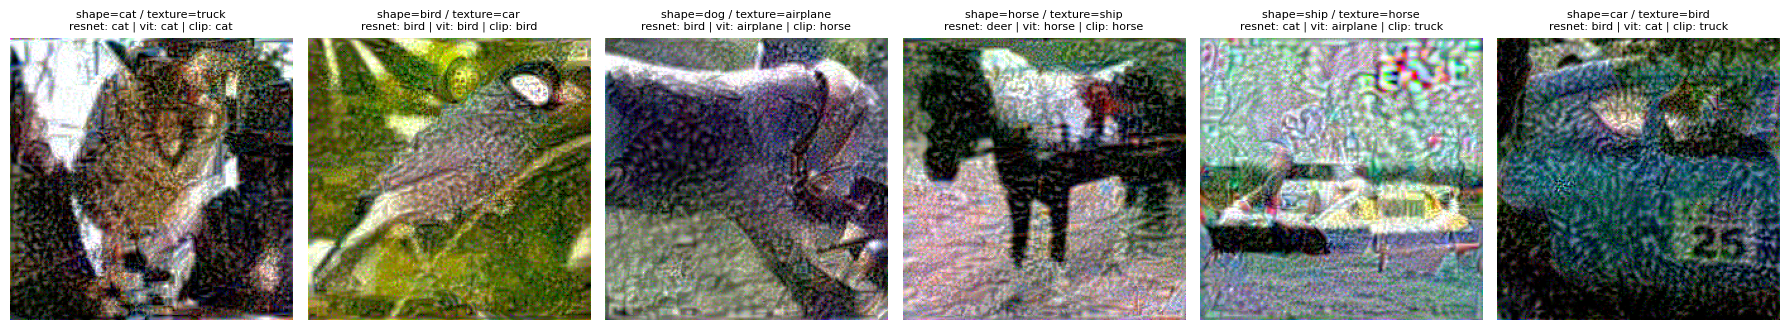

In [21]:
# --- A small set of informative cue-conflict examples (agreements/disagreements/failures) ---
n_show = 6
show_idx = np.random.RandomState(6304).choice(len(cue_data['images']), size=n_show, replace=False)
fig, axes = plt.subplots(1, n_show, figsize=(3 * n_show, 3.5))
for ax, i in zip(axes, show_idx):
    img = cue_data['images'][i].permute(1, 2, 0).numpy()
    ax.imshow(np.clip(img, 0, 1))
    c_name = CLASSES[content_labels[i]]
    s_name = CLASSES[style_labels[i]]
    pred_lines = []
    for bb in BACKBONES:
        p, _ = head_predict(bb, cue_feats[bb][0][i:i+1])
        pred_lines.append(f'{bb}: {CLASSES[p.item()]}')
    ax.set_title(f'shape={c_name} / texture={s_name}\n' + ' | '.join(pred_lines), fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.savefig('/kaggle/working/cue_conflict_examples.png', dpi=150)
plt.show()


## 7. Translation

Displacements of 0, 8, 16, 32 pixels in the four cardinal directions, via reflection-pad-then-shifted-crop, averaged across the four directions per displacement. *Hypothesis*: ViT-B/16's positional encoding and patch tokenization should make it more position-sensitive than ResNet-50 (whose convolution/pooling gives it some translation equivariance) or CLIP (a ViT with contrastive rather than classification pretraining, which may or may not preserve that sensitivity). *Metric*: accuracy and prediction consistency vs. clean, as a function of displacement.

In [23]:
def translate_transform(x, dx, dy):
    """x: (N,3,H,W) in [0,1]. Reflect-pads by max(|dx|,|dy|) then crops a window shifted by (dx,dy)."""
    pad = max(abs(dx), abs(dy))
    if pad == 0:
        return x
    x_padded = F.pad(x, (pad, pad, pad, pad), mode='reflect')
    h, w = x.shape[-2], x.shape[-1]
    top = pad - dy
    left = pad - dx
    return x_padded[:, :, top:top + h, left:left + w]

DISPLACEMENTS = [0, 8, 16, 32]
DIRECTIONS = [(1, 0), (-1, 0), (0, 1), (0, -1)]  # (dx, dy) unit steps, right/left/down/up

# Must match evaluate_all_models' own keys ('<backbone>_head' for the trained heads,
# 'clip_zeroshot' for zero-shot) -- using bare backbone names here caused a KeyError.
MODEL_NAMES = [f'{bb}_head' for bb in BACKBONES] + ['clip_zeroshot']
translation_results = {name: {'acc': [], 'cons': []} for name in MODEL_NAMES}
translation_feats_by_disp = {}

for disp in DISPLACEMENTS:
    per_dir_acc = {name: [] for name in MODEL_NAMES}
    per_dir_cons = {name: [] for name in MODEL_NAMES}
    last_feats = None
    for (ux, uy) in ([(0, 0)] if disp == 0 else DIRECTIONS):
        dx, dy = ux * disp, uy * disp
        feats = build_transformed_loader_features(lambda x, dx=dx, dy=dy: translate_transform(x, dx, dy))
        last_feats = feats
        res = evaluate_all_models(feats, eval_labels_t.numpy(), f'Translation d={disp} dir=({ux},{uy})')
        for name in MODEL_NAMES:
            per_dir_acc[name].append(res[name]['acc'])
            cons = consistency(torch.tensor(res[name]['preds']), torch.tensor(clean_results[name]['preds']))
            per_dir_cons[name].append(cons)
    translation_feats_by_disp[disp] = last_feats
    for name in MODEL_NAMES:
        translation_results[name]['acc'].append(np.mean(per_dir_acc[name]))
        translation_results[name]['cons'].append(np.mean(per_dir_cons[name]))

with open(os.path.join(CACHE_DIR, 'translation_results.json'), 'w') as f:
    json.dump({k: {'acc': v['acc'], 'cons': v['cons']} for k, v in translation_results.items()}, f)

--- Translation d=0 dir=(0,0) ---
  resnet_head    acc=95.20%  macro-F1=95.20%  mean_conf=0.670
  vit_head       acc=96.40%  macro-F1=96.41%  mean_conf=0.847
  clip_head      acc=95.40%  macro-F1=95.37%  mean_conf=0.123
  clip_zeroshot  acc=93.40%  macro-F1=93.28%  mean_conf=0.926


/tmp/ipykernel_58/2197439311.py:32: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  cons = consistency(torch.tensor(res[name]['preds']), torch.tensor(clean_results[name]['preds']))


--- Translation d=8 dir=(1,0) ---
  resnet_head    acc=95.00%  macro-F1=95.00%  mean_conf=0.671
  vit_head       acc=96.00%  macro-F1=96.02%  mean_conf=0.842
  clip_head      acc=95.60%  macro-F1=95.53%  mean_conf=0.123
  clip_zeroshot  acc=94.80%  macro-F1=94.70%  mean_conf=0.924


/tmp/ipykernel_58/2197439311.py:32: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  cons = consistency(torch.tensor(res[name]['preds']), torch.tensor(clean_results[name]['preds']))


--- Translation d=8 dir=(-1,0) ---
  resnet_head    acc=95.40%  macro-F1=95.41%  mean_conf=0.670
  vit_head       acc=96.00%  macro-F1=96.03%  mean_conf=0.842
  clip_head      acc=95.20%  macro-F1=95.16%  mean_conf=0.123
  clip_zeroshot  acc=93.40%  macro-F1=93.20%  mean_conf=0.924


...

/tmp/ipykernel_58/2197439311.py:32: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  cons = consistency(torch.tensor(res[name]['preds']), torch.tensor(clean_results[name]['preds']))


--- Translation d=32 dir=(0,1) ---
  resnet_head    acc=94.00%  macro-F1=94.06%  mean_conf=0.666
  vit_head       acc=96.20%  macro-F1=96.22%  mean_conf=0.836
  clip_head      acc=94.20%  macro-F1=94.17%  mean_conf=0.122
  clip_zeroshot  acc=92.20%  macro-F1=92.05%  mean_conf=0.918


/tmp/ipykernel_58/2197439311.py:32: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  cons = consistency(torch.tensor(res[name]['preds']), torch.tensor(clean_results[name]['preds']))


--- Translation d=32 dir=(0,-1) ---
  resnet_head    acc=94.40%  macro-F1=94.45%  mean_conf=0.665
  vit_head       acc=96.40%  macro-F1=96.42%  mean_conf=0.827
  clip_head      acc=93.20%  macro-F1=93.14%  mean_conf=0.122
  clip_zeroshot  acc=93.00%  macro-F1=92.90%  mean_conf=0.917


/tmp/ipykernel_58/2197439311.py:32: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  cons = consistency(torch.tensor(res[name]['preds']), torch.tensor(clean_results[name]['preds']))


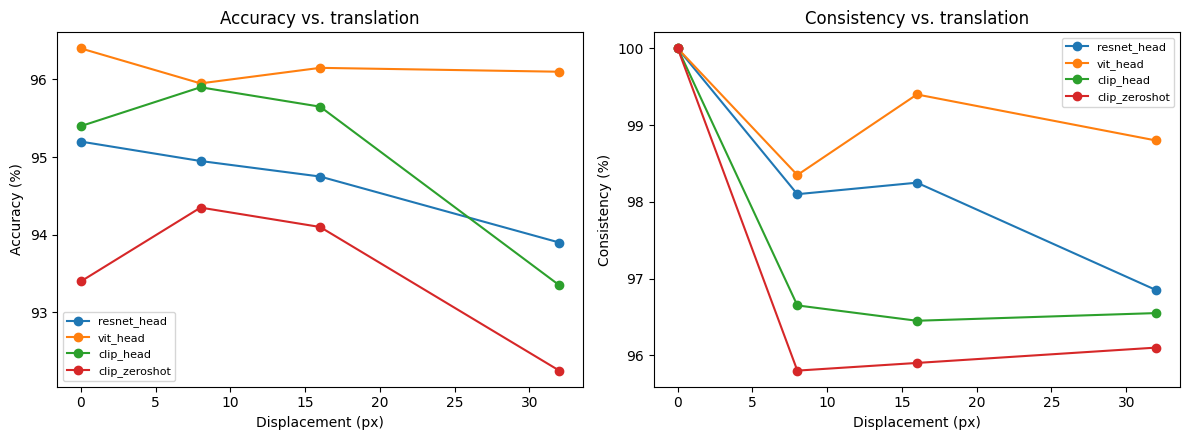

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for name, res in translation_results.items():
    axes[0].plot(DISPLACEMENTS, [a * 100 for a in res['acc']], marker='o', label=name)
    axes[1].plot(DISPLACEMENTS, [c * 100 for c in res['cons']], marker='o', label=name)
axes[0].set_xlabel('Displacement (px)'); axes[0].set_ylabel('Accuracy (%)'); axes[0].set_title('Accuracy vs. translation')
axes[1].set_xlabel('Displacement (px)'); axes[1].set_ylabel('Consistency (%)'); axes[1].set_title('Consistency vs. translation')
axes[0].legend(fontsize=8); axes[1].legend(fontsize=8)
plt.tight_layout()
plt.savefig('/kaggle/working/translation_curve.png', dpi=150)
plt.show()


## 8. Patch structure

Each image is split into a 4x4 grid of 56x56 patches and given one random non-identity permutation (seed 6304), reused identically across all three backbones. *Hypothesis*: destroying global spatial arrangement while preserving every local patch should hurt ResNet-50 comparatively little (its receptive-field hierarchy relies heavily on local texture evidence) but should hurt ViT/CLIP more, since attention over patch order plausibly encodes more global-arrangement information (Raghu et al., 2021). *Metric*: accuracy drop and prediction consistency vs. clean.

In [25]:
GRID = 4
PATCH = IMG_SIZE // GRID

def make_patch_permutation(seed):
    rng_local = np.random.RandomState(seed)
    perm = np.arange(GRID * GRID)
    while True:
        rng_local.shuffle(perm)
        if not np.array_equal(perm, np.arange(GRID * GRID)):
            return perm

def patch_shuffle_transform(x, perm):
    n = x.shape[0]
    patches = x.unfold(2, PATCH, PATCH).unfold(3, PATCH, PATCH)  # (N,3,GRID,GRID,PATCH,PATCH)
    patches = patches.contiguous().view(n, 3, GRID * GRID, PATCH, PATCH)
    patches = patches[:, :, perm, :, :]
    patches = patches.view(n, 3, GRID, GRID, PATCH, PATCH)
    out = patches.permute(0, 1, 2, 4, 3, 5).contiguous().view(n, 3, IMG_SIZE, IMG_SIZE)
    return out

# One fixed, shared permutation per image index across the whole eval subset, seed 6304.
eval_perms = [make_patch_permutation(6304 + i) for i in range(len(eval_idx))]

def patch_shuffle_batch(x, start_idx):
    outs = []
    for k in range(x.shape[0]):
        outs.append(patch_shuffle_transform(x[k:k+1], eval_perms[start_idx + k]))
    return torch.cat(outs)


In [26]:
@torch.no_grad()
def build_patch_shuffled_features():
    feats = {bb: [] for bb in BACKBONES}
    labels_out = []
    start = 0
    for x, y in eval_loader:
        x_t = patch_shuffle_batch(x, start)
        start += x.shape[0]
        for bb in BACKBONES:
            feats[bb].append(extract_features(bb, x_t))
        labels_out.append(y)
    for bb in BACKBONES:
        feats[bb] = (torch.cat(feats[bb]), torch.cat(labels_out))
    return feats

patch_feats = build_patch_shuffled_features()
patch_results = evaluate_all_models(patch_feats, eval_labels_t.numpy(), 'Patch shuffle (4x4)')
print('--- Patch shuffle vs Clean ---')
for name in patch_results:
    acc_delta = (patch_results[name]['acc'] - clean_results[name]['acc']) * 100
    cons = consistency(torch.tensor(patch_results[name]['preds']), torch.tensor(clean_results[name]['preds']))
    print(f'  {name:<14} acc Δ={acc_delta:+5.2f} pts   consistency={cons*100:5.2f}%')


--- Patch shuffle (4x4) ---
  resnet_head    acc=84.40%  macro-F1=84.40%  mean_conf=0.723
  vit_head       acc=88.80%  macro-F1=88.89%  mean_conf=0.704
  clip_head      acc=72.60%  macro-F1=73.12%  mean_conf=0.113
  clip_zeroshot  acc=77.60%  macro-F1=77.25%  mean_conf=0.761
--- Patch shuffle vs Clean ---
  resnet_head    acc Δ=-10.80 pts   consistency=86.60%
  vit_head       acc Δ=-7.60 pts   consistency=90.60%
  clip_head      acc Δ=-22.80 pts   consistency=73.80%
  clip_zeroshot  acc Δ=-15.80 pts   consistency=78.80%


/tmp/ipykernel_58/2096275874.py:21: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  cons = consistency(torch.tensor(patch_results[name]['preds']), torch.tensor(clean_results[name]['preds']))


## 9. Representation analysis

**Visualization method choice — t-SNE** (`sklearn.manifold.TSNE`, `perplexity=30`, `n_iter=1000`, `random_state=6304`), over UMAP, because t-SNE's emphasis on preserving local neighborhoods is a closer match to the question here (do transformed examples of a class stay near their clean neighbors, or drift away?) than UMAP's broader global-structure preservation. Settings and the image subset/seed are fixed across every (backbone, intervention) pair; absolute coordinates are never compared across projections fit separately per backbone. *Hypothesis*: an intervention with high cosine stability (`I_T`) for a backbone should also show tight clean/transformed overlap per class in its projection; a low-`I_T` intervention should show visible drift. *Metric*: `I_T` (quantitative) alongside the t-SNE plot (qualitative).

In [27]:
# Cosine stability I_T for the four required interventions, one displacement (16px, averaged over the
# four directions) representing translation.
def cosine_stability(clean_feats, transformed_feats):
    return F.cosine_similarity(clean_feats, transformed_feats, dim=1).mean().item()

translation16_feats = translation_feats_by_disp[16]

intervention_feats = {
    'grayscale': gray_feats,
    'cue_conflict': None,  # handled separately below (different image set / no shared labels with clean)
    'translation_16px': translation16_feats,
    'patch_shuffle': patch_feats,
}

print('--- Representation stability (I_T) ---')
I_T_table = {}
for bb in BACKBONES:
    I_T_table[bb] = {}
    for name, feats in intervention_feats.items():
        if name == 'cue_conflict':
            continue
        i_t = cosine_stability(eval_feats[bb][0], feats[bb][0])
        I_T_table[bb][name] = i_t
    print(f'  {bb}: ' + '  '.join(f'{k}={v:.4f}' for k, v in I_T_table[bb].items()))


--- Representation stability (I_T) ---
  resnet: grayscale=0.7981  translation_16px=0.9528  patch_shuffle=0.6938
  vit: grayscale=0.7316  translation_16px=0.9760  patch_shuffle=0.6270
  clip: grayscale=0.8850  translation_16px=0.9646  patch_shuffle=0.7500


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarnin

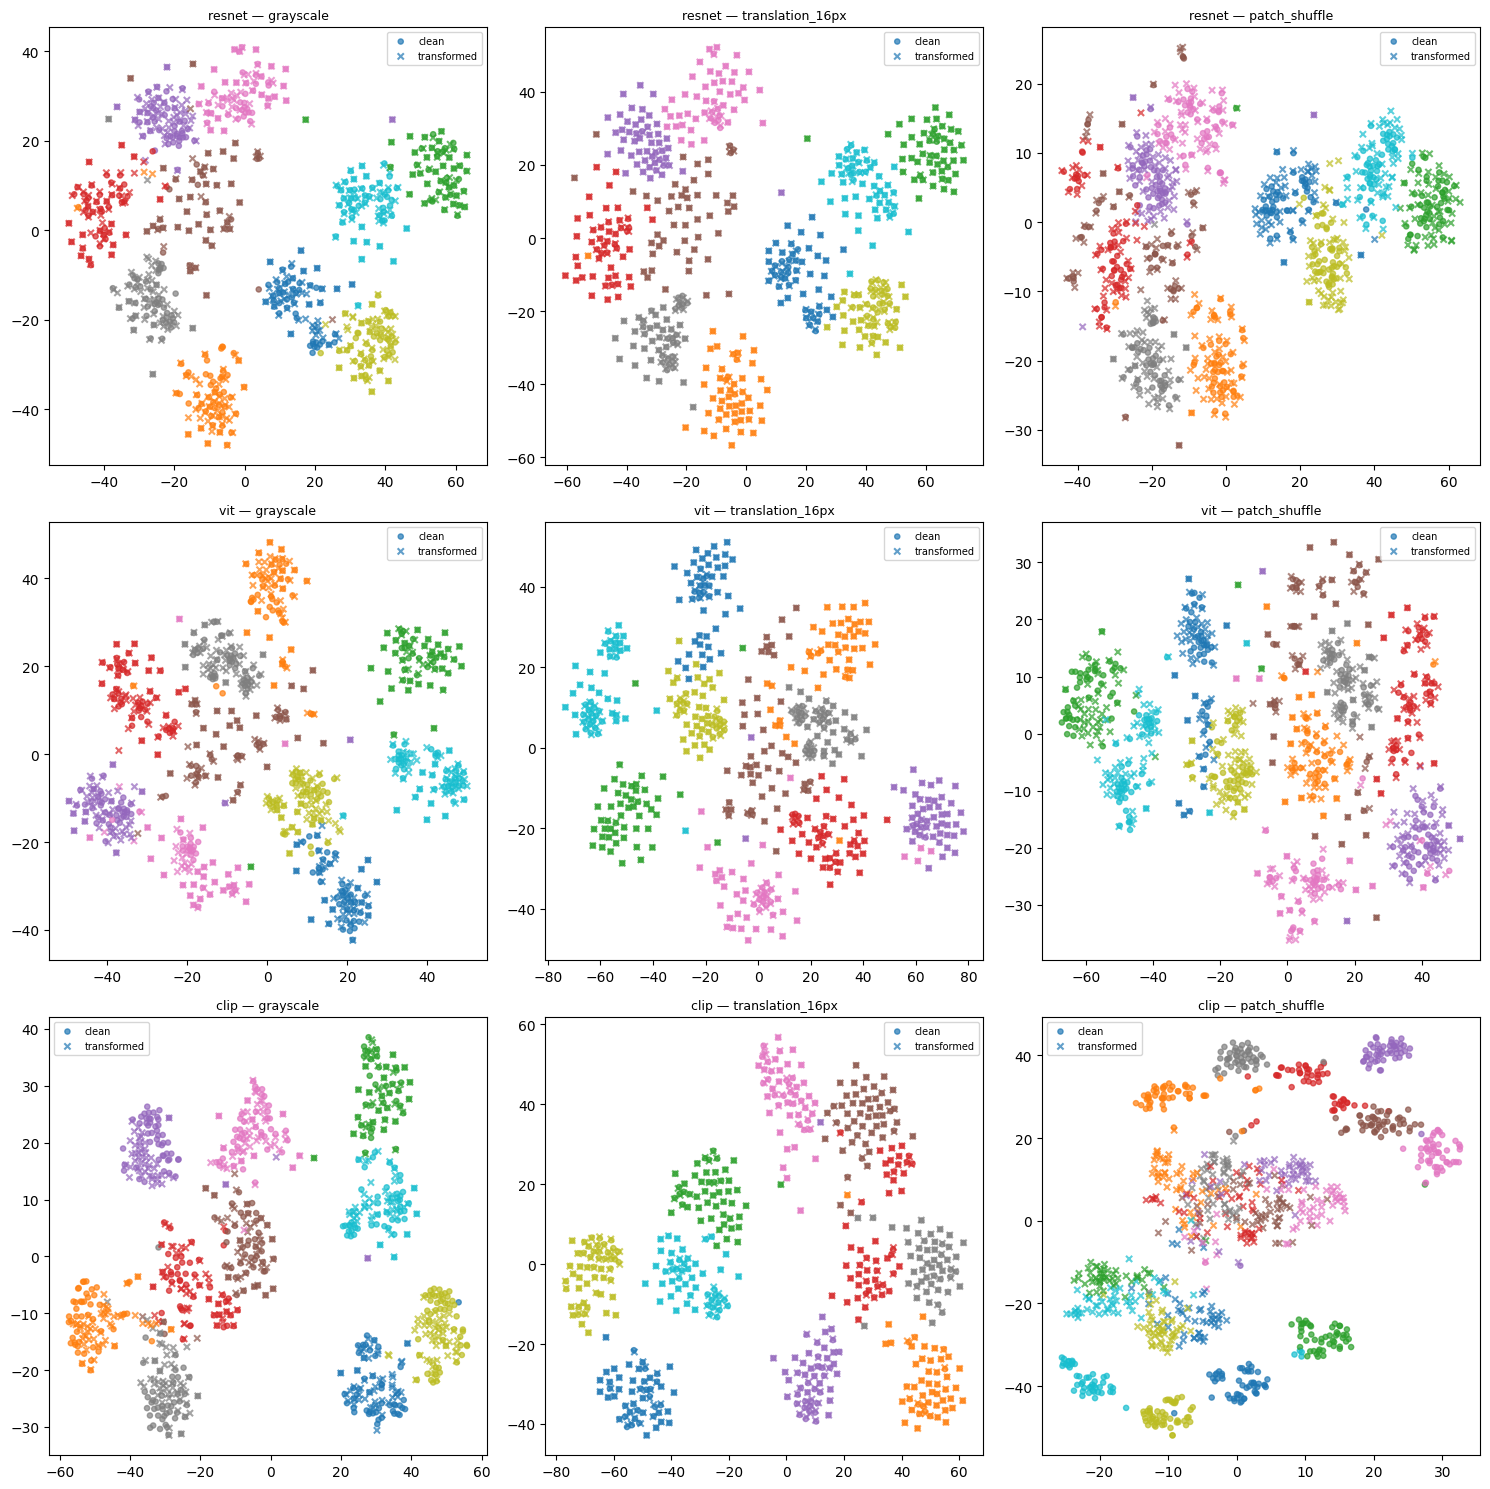

In [28]:
# t-SNE per (backbone, intervention): combined clean + transformed features, color=class, marker=condition.
def tsne_plot(bb, name, clean_f, trans_f, clean_y, trans_y, ax):
    X = torch.cat([clean_f, trans_f]).numpy()
    combined_labels = np.concatenate([clean_y, trans_y])
    is_clean = np.array([True] * len(clean_f) + [False] * len(trans_f))
    emb = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=6304, init='pca').fit_transform(X)
    scatter = ax.scatter(emb[is_clean, 0], emb[is_clean, 1], c=combined_labels[is_clean],
                          cmap='tab10', marker='o', s=14, alpha=0.7, label='clean')
    ax.scatter(emb[~is_clean, 0], emb[~is_clean, 1], c=combined_labels[~is_clean],
               cmap='tab10', marker='x', s=20, alpha=0.7, label='transformed')
    ax.set_title(f'{bb} — {name}', fontsize=9)
    ax.legend(fontsize=7)

fig, axes = plt.subplots(len(BACKBONES), 3, figsize=(15, 5 * len(BACKBONES)))
for row, bb in enumerate(BACKBONES):
    tsne_plot(bb, 'grayscale', eval_feats[bb][0], gray_feats[bb][0], eval_labels_t.numpy(),
              eval_labels_t.numpy(), axes[row, 0])
    tsne_plot(bb, 'translation_16px', eval_feats[bb][0], translation16_feats[bb][0], eval_labels_t.numpy(),
              eval_labels_t.numpy(), axes[row, 1])
    tsne_plot(bb, 'patch_shuffle', eval_feats[bb][0], patch_feats[bb][0], eval_labels_t.numpy(),
              eval_labels_t.numpy(), axes[row, 2])
plt.tight_layout()
plt.savefig('/kaggle/working/tsne_grid.png', dpi=150)
plt.show()


--- Cue-conflict representation stability (I_T), 50-image representative subsample ---
  resnet: I_T=0.1262
  vit: I_T=0.0533
  clip: I_T=0.5878


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


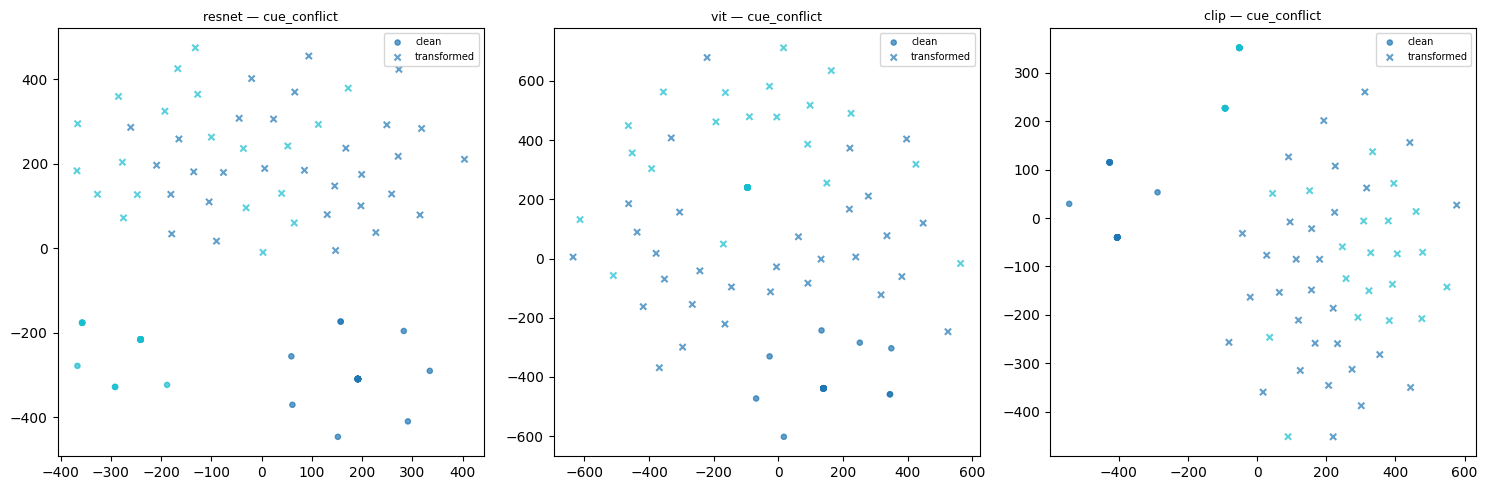

In [29]:
# Cue-conflict is a separate image set (own content/style labels rather than eval-subset labels), so its
# I_T and t-SNE compare each cue-conflict image against a freshly-extracted clean rendering of its own
# content-class source image, and its own figure.
cue_content_imgs = torch.stack([stl_test_base[sample_pool_indices(CLASSES[c.item()], 1, seed=6304)[0]][0]
                                 for c in content_labels[:50]])  # a representative subsample for speed
cue_content_feats = {bb: extract_features_tensor(bb, cue_content_imgs) for bb in BACKBONES}

print('--- Cue-conflict representation stability (I_T), 50-image representative subsample ---')
for bb in BACKBONES:
    i_t = cosine_stability(cue_content_feats[bb], cue_feats[bb][0][:50])
    I_T_table[bb]['cue_conflict'] = i_t
    print(f'  {bb}: I_T={i_t:.4f}')

fig, axes = plt.subplots(1, len(BACKBONES), figsize=(15, 5))
for col, bb in enumerate(BACKBONES):
    tsne_plot(bb, 'cue_conflict', cue_content_feats[bb], cue_feats[bb][0][:50],
              content_labels[:50].numpy(), content_labels[:50].numpy(), axes[col])
plt.tight_layout()
plt.savefig('/kaggle/working/tsne_cue_conflict.png', dpi=150)
plt.show()

with open(os.path.join(CACHE_DIR, 'I_T_table.json'), 'w') as f:
    json.dump(I_T_table, f, indent=2)


## 10. Summary

### Required-evidence checklist
- Compact clean / grayscale / hue-rotation / patch-shuffle comparison → Sections 4, 5, 8 (accuracy, macro-F1, consistency, per backbone).
- Shape / texture / other decision counts + Shape Bias% + Coverage% → Section 6.
- Translation curve (accuracy and consistency vs. displacement) → Section 7.
- Representation-stability (`I_T`) for all four required interventions + t-SNE visualizations → Section 9.
- A small set of informative cue-conflict examples with per-model predictions → Section 6 (figure).

### Research questions to address when writing the report
1. What do the color and cue-conflict experiments jointly reveal about each model's reliance on shape, texture, and color? How does coverage affect the strength of the shape-bias conclusions?
2. How do ResNet, ViT, and CLIP respond when spatial structure is altered through translation and patch shuffling? What does this suggest about locality, global organization, and positional sensitivity?
3. To what extent do prediction-level changes agree with changes in feature representations (compare accuracy/consistency against `I_T`)? Note at least one informative agreement or mismatch, and compare CLIP's zero-shot decisions against its own trained head.
4. Which observed differences can reasonably be attributed to architecture, versus pretraining data, supervision, augmentation, or model capacity? Use the results and failure cases to justify the distinction.